In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("Student_Marks.csv")

In [4]:
df.head()

,number_courses,time_study,Marks
0,3,4.508,19.202
1,4,0.096,7.734
2,4,3.133,13.811
3,6,7.909,53.018
4,8,7.811,55.299


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   number_courses  100 non-null    int64  
 1   time_study      100 non-null    float64
 2   Marks           100 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [6]:
df.describe()

,number_courses,time_study,Marks
count,100.000000,100.000000,100.000000
mean,5.290000,4.077140,24.417690
std,1.799523,2.372914,14.326199
min,3.000000,0.096000,5.609000
25%,4.000000,2.058500,12.633000
50%,5.000000,4.022000,20.059500
75%,7.000000,6.179250,36.676250
max,8.000000,7.957000,55.299000


In [8]:
from sklearn.model_selection import train_test_split

In [10]:
X = df.drop("Marks", axis=1)
y = df["Marks"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
X_train.head()

,number_courses,time_study
55,7,2.913
88,5,1.803
26,7,0.508
42,6,3.591
69,6,3.948


In [15]:
import matplotlib.pyplot as plt

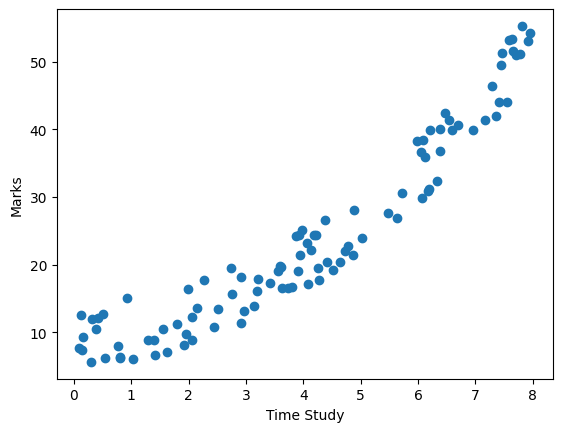

In [17]:
plt.scatter(df["time_study"], df["Marks"])
plt.xlabel("Time Study")
plt.ylabel("Marks")
plt.show()

In [18]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression



In [26]:
poly = PolynomialFeatures(2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.fit_transform(X_test)

model = LinearRegression()

model.fit(X_train_poly, y_train)

y_pred = model.predict(X_test_poly)

In [22]:
pred

array([15.87267259, 36.98722855, 16.66703044,  8.51089613,  9.91496648,
       51.28865928, 11.8599188 , 54.95676236, 41.7772048 , 19.20613109,
       50.62278185, 24.131801  ,  7.46007044, 39.8892758 , 24.14884883,
       55.15016309, 36.28633812, 38.19268169, 24.35202399,  8.1479006 ])

In [27]:
pred_df = pd.DataFrame({
    "Actual_mark" : y_test,
    "Pred_mark" : y_pred
})

In [28]:
pred_df.head()

,Actual_mark,Pred_mark
83,16.106,15.872673
53,36.653,36.987229
70,16.606,16.667030
45,8.924,8.510896
44,9.742,9.914966


In [30]:
print(X_test.shape)
print(y_test.shape)
print(y_pred.shape)

(20, 2)
(20,)
(20,)


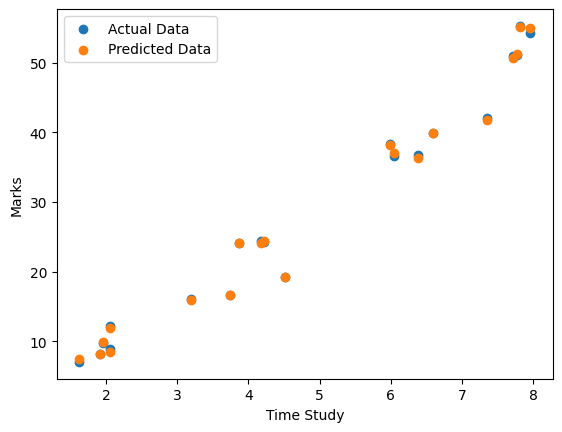

In [31]:
plt.scatter(X_test["time_study"], y_test, label="Actual Data")
plt.scatter(X_test["time_study"], y_pred, label="Predicted Data")

plt.xlabel("Time Study")
plt.ylabel("Marks")
plt.legend()
plt.show()

In [32]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test,y_pred)

r2

0.9996905196548477

In [35]:
accuracy = model.score(X_test_poly, y_test)
accuracy

0.9996905196548477